Loading data from ../../local_data/nsidc_distance_to_land.nc...


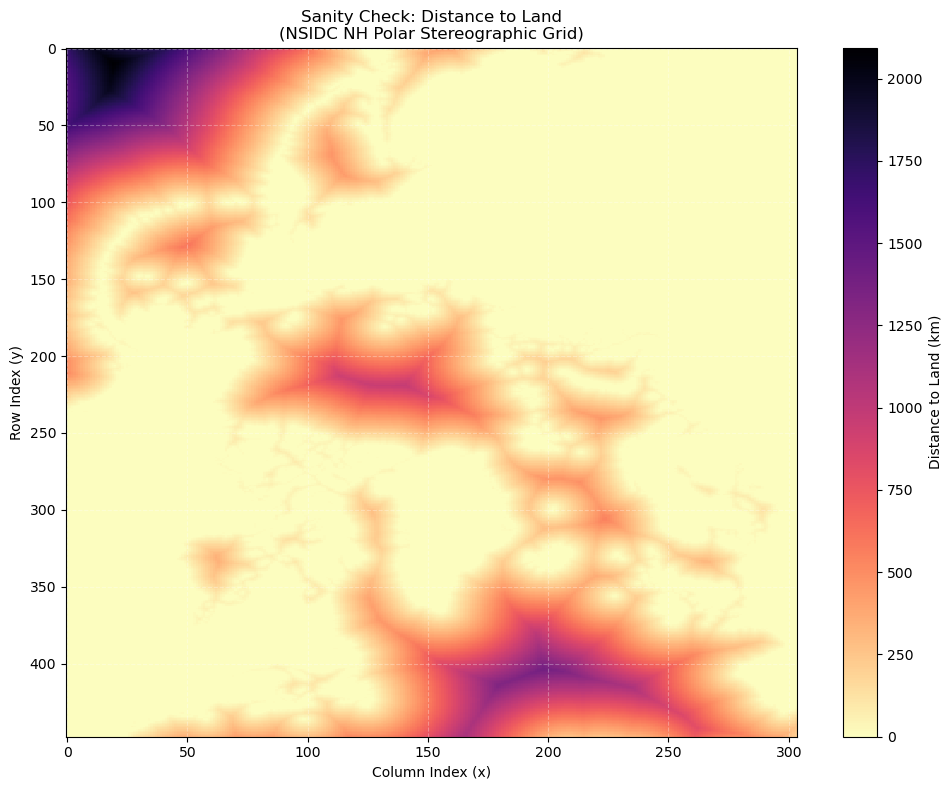

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# Path to the generated NetCDF file
file_path = '../../local_data/nsidc_distance_to_land.nc'

print(f"Loading data from {file_path}...")
try:
    ds = xr.open_dataarray(file_path)
except FileNotFoundError:
    print(f"Error: Could not find {file_path}. Make sure the generation script finished running.")
    exit()

# Convert metres to kilometres for easier interpretation on the colorbar
ds_km = ds / 1000.0
ds_km.name = 'Distance to nearest land'
ds_km.attrs['units'] = 'km'

# Setup the plot
fig, ax = plt.subplots(figsize=(10, 8))

# xarray wraps matplotlib's pcolormesh/imshow natively
# 'magma_r' or 'viridis' are great colormaps for distance (darker = closer, brighter = further)
plot = ds_km.plot(
    ax=ax,
    cmap='magma_r', 
    cbar_kwargs={'label': 'Distance to Land (km)'}
)

# The NSIDC grid typically places row 0 at the top (highest Y).
# Inverting the Y-axis makes it match a standard top-down map view.
ax.invert_yaxis()

plt.title('Sanity Check: Distance to Land\n(NSIDC NH Polar Stereographic Grid)')
plt.xlabel('Column Index (x)')
plt.ylabel('Row Index (y)')

# Add gridlines for readability
ax.grid(color='white', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Loading data...


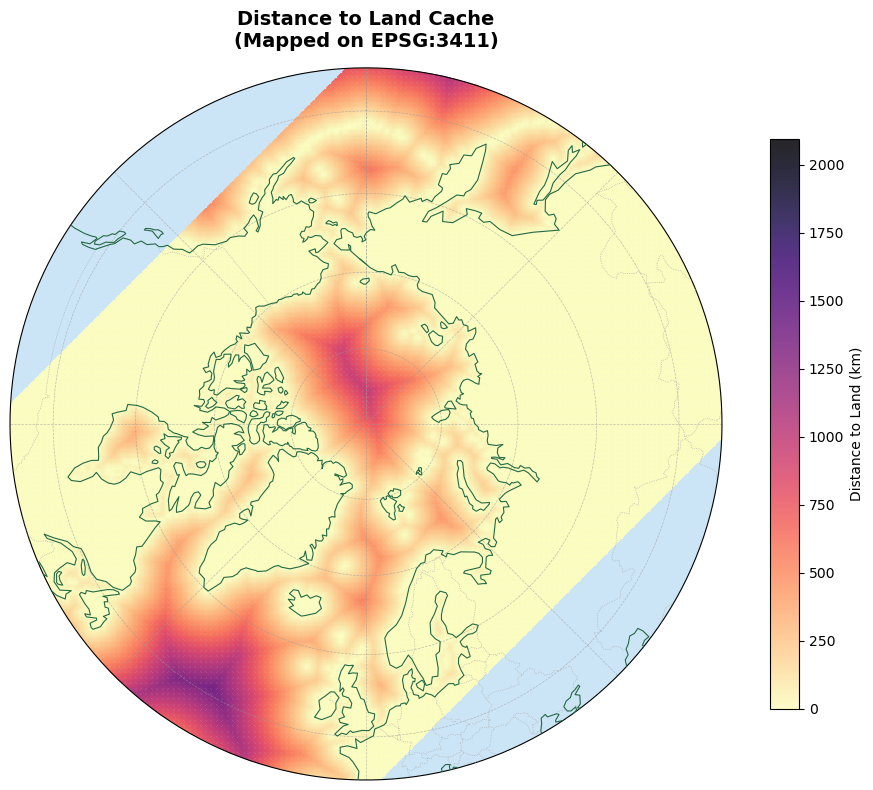

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# NSIDC NH polar stereographic grid parameters (EPSG:3411)
NROWS      = 448
NCOLS      = 304
PIXEL_SIZE = 25000   # metres
X_ORIGIN   = -3830000
Y_ORIGIN   =  5830000

print("Loading data...")
file_path = '../../local_data/nsidc_distance_to_land.nc'
ds = xr.open_dataarray(file_path)
ds_km = ds / 1000.0  # Convert to km for the plot

# Reconstruct the X and Y coordinates in EPSG:3411 meters to map the 2D array accurately
x_coords = X_ORIGIN + (np.arange(NCOLS) + 0.5) * PIXEL_SIZE
y_coords = Y_ORIGIN + (np.arange(NROWS) + 0.5) * (-PIXEL_SIZE)

# Define the native projection of the NSIDC data (EPSG:3411)
nsidc_crs = ccrs.Stereographic(
    central_latitude=90, 
    central_longitude=-45, 
    true_scale_latitude=70
)

# Define the projection for the plot map (matches your snippet)
plot_crs = ccrs.NorthPolarStereo(central_longitude=0)
data_crs = ccrs.PlateCarree()

# Setup Figure
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': plot_crs})
fig.patch.set_facecolor('white')

# 1. Add circular boundary matching your snippet style
def make_circular_boundary(ax, lat_min=45):
    theta = np.linspace(0, 2 * np.pi, 200)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.set_extent([-180, 180, lat_min, 90], crs=data_crs)

make_circular_boundary(ax, lat_min=45) # Set slightly lower than 50 to fit the whole grid

# 2. Add base colors and features
ax.set_facecolor('#cce5f6')

# 3. Plot the heatmap data
# We use pcolormesh and transform from the native NSIDC CRS to the map CRS
mesh = ax.pcolormesh(
    x_coords, y_coords, ds_km.values,
    transform=nsidc_crs,
    cmap='magma_r',
    alpha=0.85,  # Slight transparency to let the map feel integrated
    zorder=2
)

# 4. Overlay cartopy coastlines and borders so land stands out
ax.add_feature(cfeature.COASTLINE, edgecolor="#256844", linewidth=0.8, zorder=3)
ax.add_feature(cfeature.BORDERS, edgecolor='#aaaaaa', linewidth=0.5, linestyle=':', zorder=3)

# 5. Add Gridlines
gl = ax.gridlines(
    crs=data_crs,
    draw_labels=False,
    linewidth=0.5,
    color='#999999',
    alpha=0.6,
    linestyle='--',
    zorder=4
)
gl.ylocator = plt.FixedLocator([50, 60, 70, 80])
gl.xlocator = plt.FixedLocator(np.arange(-180, 181, 45))

# 6. Formatting
cbar = plt.colorbar(mesh, ax=ax, shrink=0.8, pad=0.05, label='Distance to Land (km)')
ax.set_title('Distance to Land Cache\n(Mapped on EPSG:3411)', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

Loading visual data from ../../local_data/DataFrames/validation_2024.csv...
Best test day found: 2024-05-01 (Found 189 visual points)

Authenticating NASA earthaccess...
Fetching NASA Team data for 2024-05-01...


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

Opening daily NASA Team data into array...

Generating sanity check plot...


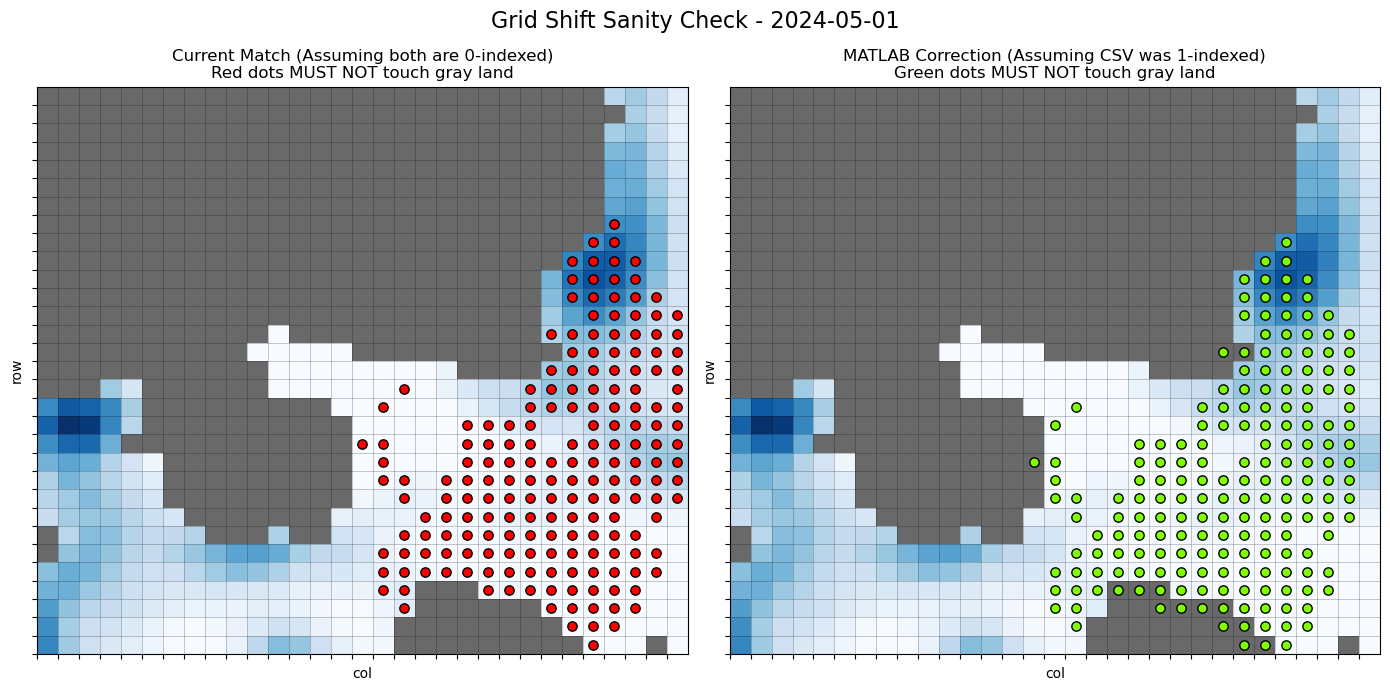

In [9]:
import earthaccess
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# ==========================================
# 1. LOAD VISUAL DATA & FIND BEST TEST DAY
# ==========================================
year = "2024" # Change to whichever validation file you have handy
csv_path = f'../../local_data/DataFrames/validation_{year}.csv'

print(f"Loading visual data from {csv_path}...")
df = pd.read_csv(csv_path)

# Define our coastal zoom window
col_min, col_max = 50, 80
row_min, row_max = 170, 200

# Filter the visual dataframe to this bounding box
vis_df = df[(df['col'] >= col_min) & (df['col'] <= col_max) & 
            (df['row'] >= row_min) & (df['row'] <= row_max)].copy()

# Find the specific day with the most data in this window
best_day_str = vis_df['time'].value_counts().idxmax()
# Format the date exactly how earthaccess expects it (YYYY-MM-DD)
date_str = pd.to_datetime(best_day_str).strftime('%Y-%m-%d') 

vis_df = vis_df[vis_df['time'] == best_day_str]
print(f"Best test day found: {date_str} (Found {len(vis_df)} visual points)")

# ==========================================
# 2. FETCH PASSIVE MICROWAVE DATA VIA NASA
# ==========================================
print('\nAuthenticating NASA earthaccess...')
auth = earthaccess.login(strategy='interactive', persist=True)

# Fetch ONLY the single day we need to save time
print(f'Fetching NASA Team data for {date_str}...')
results = earthaccess.search_data(
    short_name='NSIDC-0051',
    temporal=(date_str, date_str),
    bounding_box=(-180, 0, 180, 90),
    cloud_hosted=True
)

filtered_results = [
    g for g in results
    if re.search(r'_20\d{6}_', g.data_links(access='external')[0])
]

files_team = earthaccess.open(filtered_results)

print('Opening daily NASA Team data into array...')
ds = xr.open_mfdataset(
    files_team,
    concat_dim="time",
    combine="nested",
    data_vars='minimal',
    coords='minimal',
    compat='override'
)

# Apply your exact pipeline logic
icecon_vars = sorted([var for var in ds.data_vars if 'ICECON' in var], reverse=True)
icecon = ds[icecon_vars].to_array("source").max("source", skipna=True)
ds = ds.assign(team_icecon=icecon).drop_vars(icecon_vars)

nrows = ds.sizes['y']
ncols = ds.sizes['x']

ds = ds.assign_coords({
    'row': ('y', np.arange(nrows)),
    'col': ('x', np.arange(ncols))
}).swap_dims({'y': 'row', 'x': 'col'})

# ==========================================
# 3. PLOT: THE DEFINITIVE 1-INDEX CHECK
# ==========================================
print('\nGenerating sanity check plot...')
# Subset the xarray PMW dataset to the zoom window
ds_zoom = ds.sel(col=slice(col_min, col_max), row=slice(row_min, row_max))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Set up colormap to explicitly show land as dark gray
cmap = plt.get_cmap('Blues_r').copy()
cmap.set_over('dimgray') # Forces values > 1.0 (often land) to be dark gray
cmap.set_bad('dimgray')  # Forces NaN (often land) to be dark gray

# Loop to draw the base map and physical gridlines on both plots
for ax in [ax1, ax2]:
    # Plot PMW base map, capping the colorbar at 1.001 so land gets colored gray
    ds_zoom.team_icecon.mean(dim='time').plot(
        ax=ax, cmap=cmap, vmax=1.001, add_colorbar=False
    )
    
    # Draw exact physical pixel gridlines at the half-integers
    ax.set_xticks(np.arange(col_min - 0.5, col_max + 0.5, 1))
    ax.set_yticks(np.arange(row_min - 0.5, row_max + 0.5, 1))
    ax.grid(which='major', color='black', linestyle='-', linewidth=0.5, alpha=0.3)
    
    # Hide axis tick marks but keep labels for clarity
    ax.set_xticks(np.arange(col_min, col_max, 2), minor=True)
    ax.set_yticks(np.arange(row_min, row_max, 2), minor=True)
    ax.tick_params(which='minor', bottom=False, left=False, labelbottom=True, labelleft=True)
    ax.tick_params(which='major', labelbottom=False, labelleft=False)

# --- PLOT 1: Your Current Match (0-Shift) ---
# If this is right, the red dots will trace the coastline perfectly.
ax1.scatter(vis_df['col'], vis_df['row'], color='red', s=45, edgecolor='black', zorder=5)
ax1.set_title("Current Match (Assuming both are 0-indexed)\nRed dots MUST NOT touch gray land")

# --- PLOT 2: MATLAB Correction (-1 Shift) ---
# If your CSV was 1-indexed, this shifted map will be the correct alignment.
ax2.scatter(vis_df['col'] - 1, vis_df['row'] - 1, color='chartreuse', s=45, edgecolor='black', zorder=5)
ax2.set_title("MATLAB Correction (Assuming CSV was 1-indexed)\nGreen dots MUST NOT touch gray land")

plt.suptitle(f"Grid Shift Sanity Check - {date_str}", fontsize=16)
plt.tight_layout()
plt.show()